# 08c 최종 모델 — 리드타임 분석

**운영점**: T=0.4106 (FAR 1% 타겟), 30일 윈도우

**분류 기준** (07a 동일):
- ✅ **TP**: 첫 알람이 `failure=1` 구간 내 발생
- ❌ **FP-Normal**: 정상 디스크에서 알람 발생
- ⚠️ **FP-Early**: 고장 디스크지만 첫 알람이 `failure=0` 구간 (>30일 전)
- 🔇 **FN**: 고장 디스크인데 한 번도 탐지 못 함

In [1]:
import os, sys, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import Counter
import matplotlib.font_manager as fm

warnings.filterwarnings("ignore")

for _fn in ["Malgun Gothic","NanumGothic","AppleGothic","DejaVu Sans"]:
    if any(_fn.lower() in f.name.lower() for f in fm.fontManager.ttflist):
        plt.rcParams["font.family"] = _fn; break
plt.rcParams["axes.unicode_minus"] = False

_cwd = Path(os.getcwd())
ROOT = _cwd.parent if _cwd.name == "notebooks2" else _cwd
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import config.final_eval_config as cfg
from src.eval_core import load_saved_ensemble

artifacts    = load_saved_ensemble(cfg, require_threshold=True)
ensemble     = artifacts["ensemble"]
feature_cols = artifacts["feature_cols"]
threshold_meta = artifacts["threshold_meta"]
op_points    = threshold_meta["operating_points"]

T_REF = 0.41058958958958963   # 1% FAR 운영점
print(f"기준 임계값: T={T_REF:.4f}")
print(f"운영점 목록: {[op['far_cap'] for op in op_points]}")


[Data Path Contract]
  [OK] model save directory: C:\Workspace\06_ML_projdect\26_1_COIN\notebooks2\models2\06d_optuna_tuning\seed_42
  [OK] feature columns: C:\Workspace\06_ML_projdect\26_1_COIN\notebooks2\models2\06d_optuna_tuning\seed_42\feature_cols.json (386 bytes)
  [OK] best threshold metadata: C:\Workspace\06_ML_projdect\26_1_COIN\notebooks2\models2\06d_optuna_tuning\seed_42\best_threshold.json (1,586 bytes)
[Model Artifact Contract]
  model_dir: C:\Workspace\06_ML_projdect\26_1_COIN\notebooks2\models2\06d_optuna_tuning\seed_42
  feature_cols: C:\Workspace\06_ML_projdect\26_1_COIN\notebooks2\models2\06d_optuna_tuning\seed_42\feature_cols.json (17 features)
  threshold_path: C:\Workspace\06_ML_projdect\26_1_COIN\notebooks2\models2\06d_optuna_tuning\seed_42\best_threshold.json
  threshold: 0.487513
  threshold_source_val_calib: c:\Workspace\06_ML_projdect\26_1_COIN\data2\03_splitting\val_calib.parquet
  model: subset_00.pkl (297,156 bytes)
  model: subset_01.pkl (296,948 bytes)
 

      → 0.0s


  joblib 로드 2/5: subset_01.pkl


      → 0.0s


  joblib 로드 3/5: subset_02.pkl


...

  joblib 로드 4/5: subset_03.pkl


      → 0.0s


  joblib 로드 5/5: subset_04.pkl


      → 0.0s


기준 임계값: T=0.4106
운영점 목록: [0.001, 0.005, 0.01, 0.02]


In [2]:
print("데이터 로드 및 추론...")
test_path = Path(cfg.TEST_PATH)
df = pd.read_parquet(test_path)
print(f"  rows={len(df):,}  failure_rows={df['failure'].sum():,}  serials={df['serial_number'].nunique():,}")

cache_path = Path(cfg.MODEL_SAVE_DIR) / f"{test_path.stem}_probs.npy"
if cache_path.exists():
    y_prob = np.load(cache_path)
    if len(y_prob) != len(df):
        y_prob = None
else:
    y_prob = None

if y_prob is None:
    print("  앙상블 추론 중...")
    y_prob = ensemble.predict_proba(df, feature_cols, verbose=True)
    np.save(cache_path, y_prob)

df["_prob"] = y_prob
df["_base"] = df["serial_number"].str.replace(r'_\d+$','',regex=True)
df["date"]  = pd.to_datetime(df["date"])
df = df.sort_values(["_base","date"])

disks = []
for base_sn, grp in df.groupby("_base", sort=False):
    disks.append({
        "base_serial": base_sn,
        "is_failed":   int(grp["failure"].max()),
        "probs":       grp["_prob"].values,
        "failures":    grp["failure"].values,
        "dates":       grp["date"].values,
    })

n_failed = sum(d["is_failed"] for d in disks)
n_normal = len(disks) - n_failed
failed_disks = [d for d in disks if d["is_failed"]]
normal_disks = [d for d in disks if not d["is_failed"]]
normal_max_probs = np.array([d["probs"].max() for d in normal_disks])
print(f"\n디스크: 총 {len(disks):,}  고장 {n_failed:,}  정상 {n_normal:,}")

데이터 로드 및 추론...


  rows=15,373,460  failure_rows=34,473  serials=16,804



디스크: 총 7,381  고장 1,135  정상 6,246


In [3]:
def classify_disks(T):
    """디스크를 TP/FP-Normal/FP-Early/FN 으로 분류. 07a 동일 기준"""
    tp_list, fp_normal_list, fp_early_list, fn_list = [], [], [], []

    for d in normal_disks:
        alarm_count = int(np.sum(d["probs"] >= T))
        if alarm_count > 0:
            fp_normal_list.append({"base_serial": d["base_serial"], "alarm_days": alarm_count})

    for d in failed_disks:
        alarm_idx = np.where(d["probs"] >= T)[0]
        if len(alarm_idx) == 0:
            fn_list.append({"base_serial": d["base_serial"]})
            continue
        first_idx = alarm_idx[0]
        if d["failures"][first_idx] == 1:
            # 첫 알람이 failure=1 구간 → TP
            trigger_date  = pd.Timestamp(d["dates"][first_idx])
            last_fail_date = pd.Timestamp(d["dates"][d["failures"]==1][-1])
            lead_time = (last_fail_date - trigger_date).days
            total_alarms_in_window = int(np.sum(d["probs"][d["failures"]==1] >= T))
            tp_list.append({
                "base_serial": d["base_serial"],
                "lead_time":   lead_time,
                "trigger_date": trigger_date,
                "total_alarms_in_window": total_alarms_in_window,
            })
        else:
            # 첫 알람이 failure=0 구간 → FP-Early (조기 오탐)
            trigger_date  = pd.Timestamp(d["dates"][first_idx])
            last_fail_date = pd.Timestamp(d["dates"][d["failures"]==1][-1])
            days_early = (last_fail_date - trigger_date).days
            early_alarm_days = int(np.sum(d["probs"][d["failures"]==0] >= T))
            fn_list.append({"base_serial": d["base_serial"]})   # 탐지 실패로 분류
            fp_early_list.append({
                "base_serial":     d["base_serial"],
                "days_early":      days_early,
                "early_alarm_days": early_alarm_days,
            })

    return (pd.DataFrame(tp_list), pd.DataFrame(fp_normal_list),
            pd.DataFrame(fp_early_list), pd.DataFrame(fn_list))

tp, fp_n, fp_e, fn = classify_disks(T_REF)

print(f"T = {T_REF:.4f}  (FAR 1% 운영점)")
print(f"  ✅ TP  (탐지 성공)    : {len(tp):,} 개  ({len(tp)/n_failed*100:.1f}%)")
print(f"  ❌ FP-Normal (순수 오탐) : {len(fp_n):,} 개  ({len(fp_n)/n_normal*100:.2f}%)")
print(f"  ⚠️ FP-Early (조기 오탐)  : {len(fp_e):,} 개")
print(f"  🔇 FN  (미탐)         : {len(fn):,} 개  ({len(fn)/n_failed*100:.1f}%)")
print(f"  Precision = {len(tp)/(len(tp)+len(fp_n))*100:.2f}%")

T = 0.4106  (FAR 1% 운영점)
  ✅ TP  (탐지 성공)    : 321 개  (28.3%)
  ❌ FP-Normal (순수 오탐) : 73 개  (1.17%)
  ⚠️ FP-Early (조기 오탐)  : 126 개
  🔇 FN  (미탐)         : 814 개  (71.7%)
  Precision = 81.47%


## 1. 전체 운영점별 성능 테이블

In [4]:
rows = []
for op in op_points:
    T = op["threshold"]
    tp_, fp_n_, fp_e_, fn_ = classify_disks(T)
    rows.append({
        "FAR 타겟":   f"{op['far_cap']*100:.1f}%",
        "Threshold":  f"{T:.4f}",
        "Disk FAR":   f"{len(fp_n_)/n_normal*100:.2f}%",
        "Recall":     f"{len(tp_)/n_failed*100:.2f}%",
        "Precision":  f"{len(tp_)/(len(tp_)+len(fp_n_))*100:.2f}%" if (len(tp_)+len(fp_n_))>0 else "N/A",
        "TP":  len(tp_), "FP-Normal": len(fp_n_),
        "FP-Early": len(fp_e_), "FN": len(fn_),
    })
df_tbl = pd.DataFrame(rows)
from IPython.display import display, HTML
display(HTML("<h4>테스트셋 운영점별 성능 (07a 동일 TP 기준)</h4>"))
display(df_tbl)

,FAR 타겟,Threshold,Disk FAR,Recall,Precision,TP,FP-Normal,FP-Early,FN
0,0.1%,0.6354,0.13%,14.36%,95.32%,163,8,32,972
1,0.5%,0.4875,0.82%,25.11%,84.82%,285,51,100,850
2,1.0%,0.4106,1.17%,28.28%,81.47%,321,73,126,814
3,2.0%,0.2937,2.35%,31.63%,70.95%,359,147,215,776


## 2. 혼동행렬 히트맵

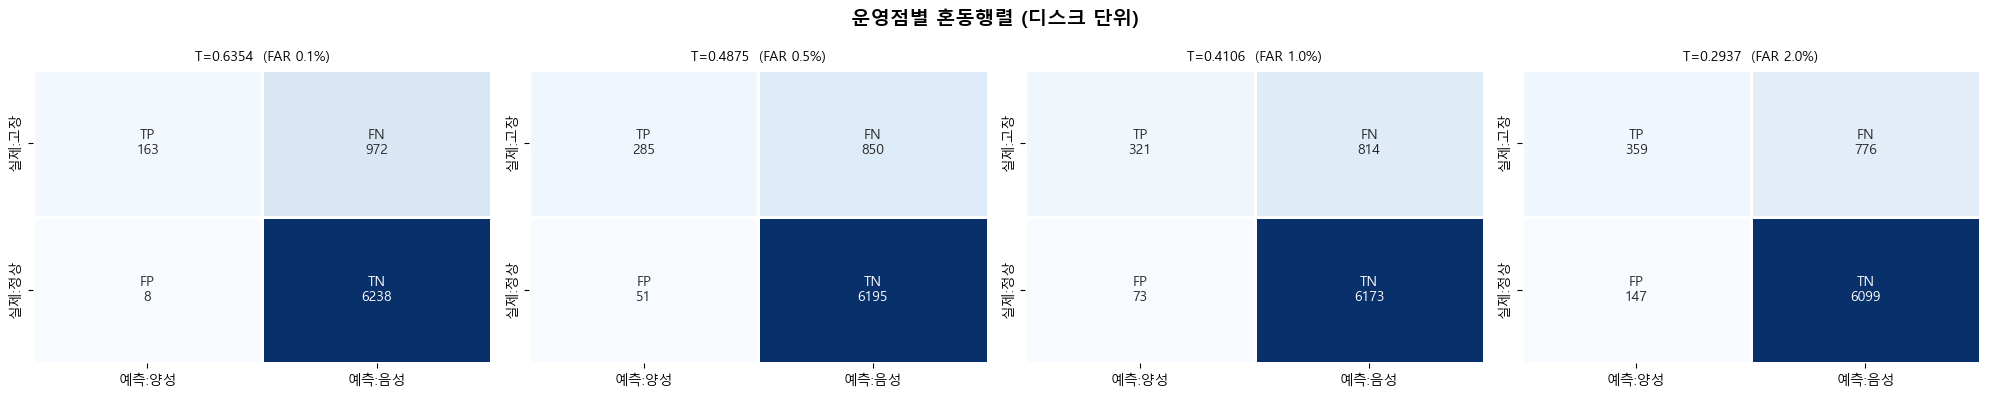

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("운영점별 혼동행렬 (디스크 단위)", fontsize=14, fontweight="bold")

for ax, op in zip(axes, op_points):
    T = op["threshold"]
    tp_, fp_n_, fp_e_, fn_ = classify_disks(T)
    # 실제 FN = fn_(완전미탐) + fp_e_(조기오탐도 탐지 실패)
    actual_fn = len(fn_)
    mat = np.array([[len(tp_), actual_fn],
                    [len(fp_n_), n_normal-len(fp_n_)]])
    labels = [[f"TP\n{len(tp_)}", f"FN\n{actual_fn}"],
              [f"FP\n{len(fp_n_)}", f"TN\n{n_normal-len(fp_n_)}"]]
    sns.heatmap(mat, annot=np.array(labels), fmt="", cmap="Blues",
                xticklabels=["예측:양성","예측:음성"],
                yticklabels=["실제:고장","실제:정상"], ax=ax,
                cbar=False, linewidths=1)
    ax.set_title(f"T={T:.4f}  (FAR {op['far_cap']*100:.1f}%)", fontsize=10)

plt.tight_layout()
os.makedirs("reports2/plots", exist_ok=True)
plt.savefig("reports2/plots/08c_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. TP 리드타임 분석 (T=0.4106 기준)

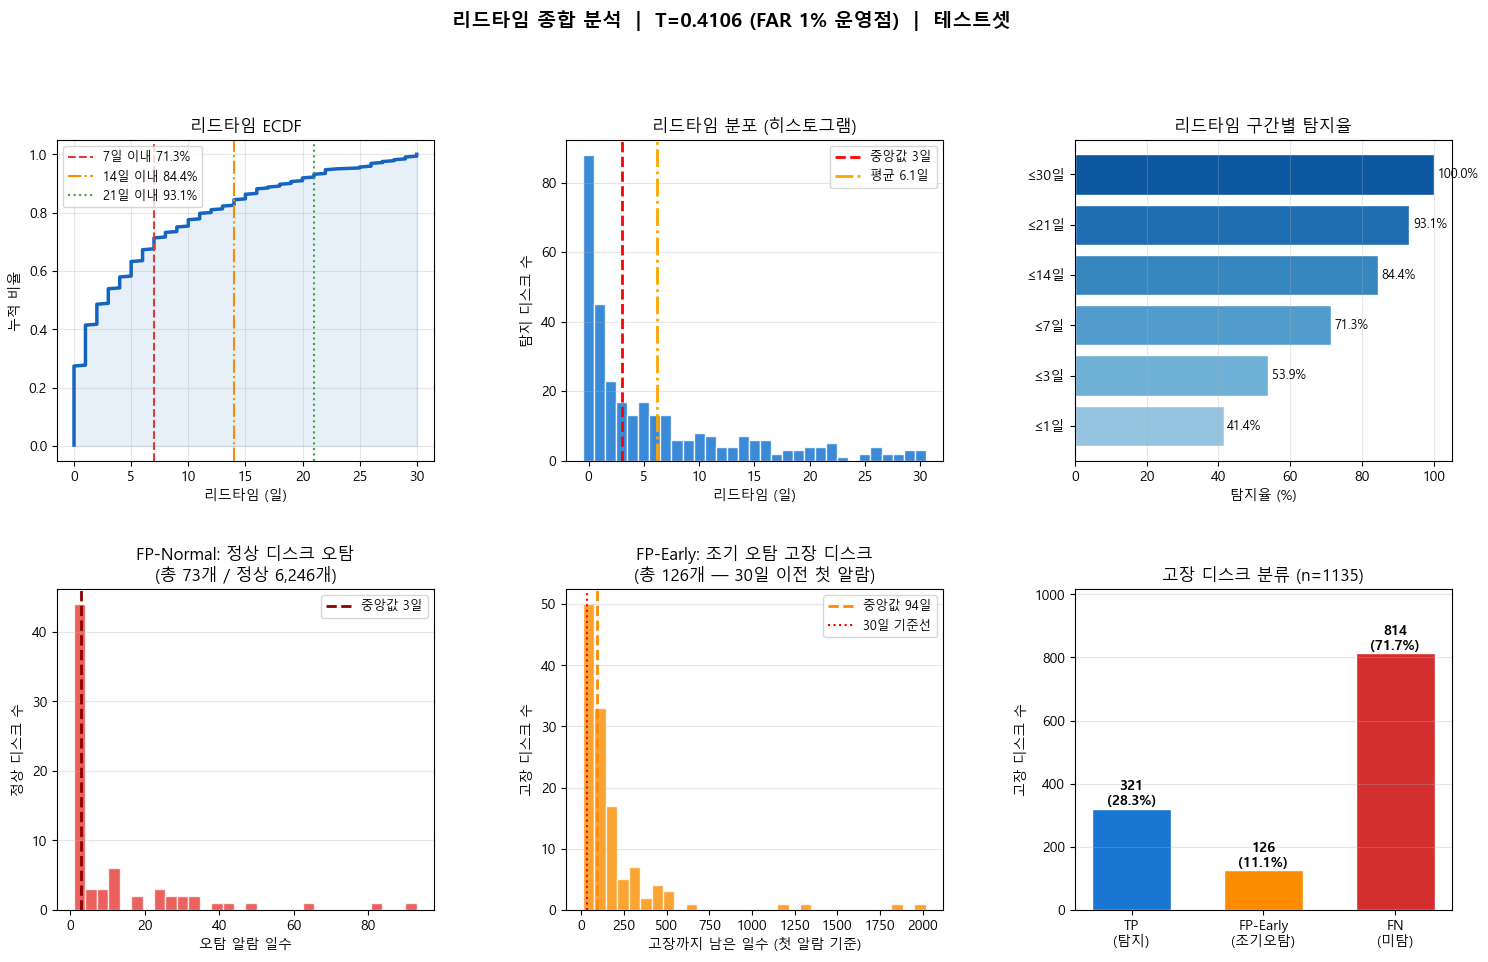

저장: reports2/plots/08c_leadtime_full.png


In [6]:
lead_times = tp["lead_time"].values
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# (0,0) ECDF
ax0 = fig.add_subplot(gs[0, 0])
sorted_lt = np.sort(lead_times)
ecdf_y    = np.arange(1, len(sorted_lt)+1) / len(sorted_lt)
ax0.plot(sorted_lt, ecdf_y, lw=2.5, color="#1565C0")
ax0.fill_between(sorted_lt, ecdf_y, alpha=0.1, color="#1565C0")
for d, c, ls in [(7,"#E53935","--"),(14,"#FB8C00","-."),(21,"#43A047",":")]:
    pct = (lead_times <= d).mean()*100
    ax0.axvline(d, color=c, ls=ls, lw=1.5, label=f"{d}일 이내 {pct:.1f}%")
ax0.set_xlabel("리드타임 (일)"); ax0.set_ylabel("누적 비율")
ax0.set_title("리드타임 ECDF"); ax0.legend(fontsize=9); ax0.grid(alpha=0.3)

# (0,1) 히스토그램
ax1 = fig.add_subplot(gs[0, 1])
ax1.hist(lead_times, bins=31, range=(-0.5,30.5), color="#1976D2", edgecolor="white", alpha=0.85)
ax1.axvline(np.median(lead_times), color="red", lw=2, ls="--", label=f"중앙값 {np.median(lead_times):.0f}일")
ax1.axvline(np.mean(lead_times),   color="orange", lw=2, ls="-.", label=f"평균 {np.mean(lead_times):.1f}일")
ax1.set_xlabel("리드타임 (일)"); ax1.set_ylabel("탐지 디스크 수")
ax1.set_title("리드타임 분포 (히스토그램)"); ax1.legend(fontsize=9); ax1.grid(axis="y",alpha=0.3)

# (0,2) 구간별 탐지율 누적 바
ax2 = fig.add_subplot(gs[0, 2])
bins_d = [1,3,7,14,21,30]
pcts   = [(lead_times<=d).mean()*100 for d in bins_d]
bars   = ax2.barh([f"≤{d}일" for d in bins_d], pcts,
                  color=plt.cm.Blues(np.linspace(0.4,0.85,len(bins_d))), edgecolor="white")
ax2.set_xlim(0,105); ax2.set_xlabel("탐지율 (%)")
ax2.set_title("리드타임 구간별 탐지율")
for bar, pct in zip(bars, pcts):
    ax2.text(pct+1, bar.get_y()+bar.get_height()/2, f"{pct:.1f}%", va="center", fontsize=9)
ax2.grid(axis="x", alpha=0.3)

# (1,0) 정상 디스크 순수 오탐 (FP-Normal)
ax3 = fig.add_subplot(gs[1, 0])
if len(fp_n) > 0:
    alarm_days = fp_n["alarm_days"].values
    ax3.hist(alarm_days, bins=min(30, alarm_days.max()), color="#E53935", edgecolor="white", alpha=0.8)
    ax3.axvline(np.median(alarm_days), color="darkred", lw=2, ls="--",
                label=f"중앙값 {np.median(alarm_days):.0f}일")
ax3.set_xlabel("오탐 알람 일수"); ax3.set_ylabel("정상 디스크 수")
ax3.set_title(f"FP-Normal: 정상 디스크 오탐\n(총 {len(fp_n):,}개 / 정상 {n_normal:,}개)")
ax3.legend(fontsize=9); ax3.grid(axis="y", alpha=0.3)

# (1,1) FP-Early (조기 오탐)
ax4 = fig.add_subplot(gs[1, 1])
if len(fp_e) > 0:
    early_d = fp_e["days_early"].values
    ax4.hist(early_d, bins=30, color="#FB8C00", edgecolor="white", alpha=0.8)
    ax4.axvline(np.median(early_d), color="darkorange", lw=2, ls="--",
                label=f"중앙값 {np.median(early_d):.0f}일")
    ax4.axvline(30, color="red", lw=1.5, ls=":", label="30일 기준선")
ax4.set_xlabel("고장까지 남은 일수 (첫 알람 기준)"); ax4.set_ylabel("고장 디스크 수")
ax4.set_title(f"FP-Early: 조기 오탐 고장 디스크\n(총 {len(fp_e):,}개 — 30일 이전 첫 알람)")
ax4.legend(fontsize=9); ax4.grid(axis="y", alpha=0.3)

# (1,2) FN 통계
ax5 = fig.add_subplot(gs[1, 2])
categories = ["TP\n(탐지)","FP-Early\n(조기오탐)","FN\n(미탐)"]
counts     = [len(tp), len(fp_e), len(fn)]
colors     = ["#1976D2","#FB8C00","#D32F2F"]
bars5 = ax5.bar(categories, counts, color=colors, edgecolor="white", width=0.6)
for bar, cnt in zip(bars5, counts):
    ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             f"{cnt}\n({cnt/n_failed*100:.1f}%)", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax5.set_ylabel("고장 디스크 수"); ax5.set_title(f"고장 디스크 분류 (n={n_failed})")
ax5.set_ylim(0, max(counts)*1.25); ax5.grid(axis="y", alpha=0.3)

fig.suptitle(f"리드타임 종합 분석  |  T={T_REF:.4f} (FAR 1% 운영점)  |  테스트셋",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig("reports2/plots/08c_leadtime_full.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장: reports2/plots/08c_leadtime_full.png")

## 4. 운영점별 리드타임 Box Plot 비교

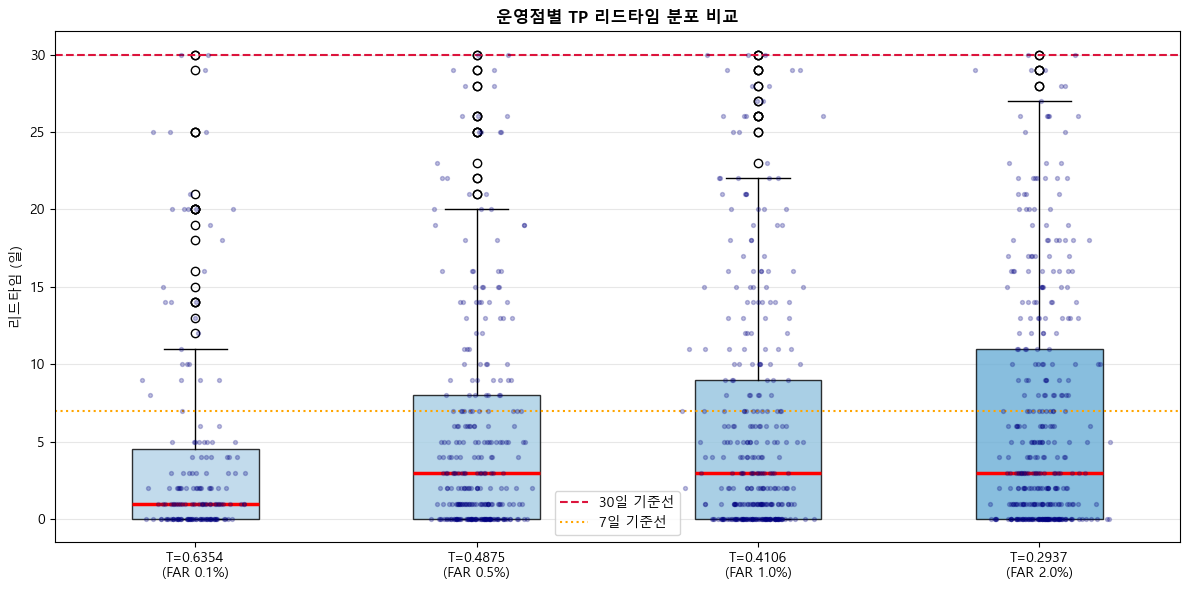

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

all_lts, labels_box, colors_box = [], [], []
for op in op_points:
    T = op["threshold"]
    tp_, *_ = classify_disks(T)
    if len(tp_) > 0:
        all_lts.append(tp_["lead_time"].values)
        labels_box.append(f"T={T:.4f}\n(FAR {op['far_cap']*100:.1f}%)")
        colors_box.append(plt.cm.Blues(0.3 + op['far_cap']*10))

bp = ax.boxplot(all_lts, labels=labels_box, patch_artist=True,
                medianprops=dict(color="red", lw=2.5))
for patch, c in zip(bp["boxes"], colors_box):
    patch.set_facecolor(c); patch.set_alpha(0.8)
for pos, lts in enumerate(all_lts, 1):
    ax.scatter(np.random.normal(pos, 0.08, size=len(lts)), lts,
               alpha=0.25, s=8, color="navy", zorder=3)

ax.axhline(30, color="crimson", ls="--", lw=1.5, label="30일 기준선")
ax.axhline(7,  color="orange",  ls=":",  lw=1.5, label="7일 기준선")
ax.set_ylabel("리드타임 (일)"); ax.set_title("운영점별 TP 리드타임 분포 비교", fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("reports2/plots/08c_leadtime_boxplot.png", dpi=150)
plt.show()

## 5. 리드타임 구간별 누적 탐지율 (전체 운영점 비교)

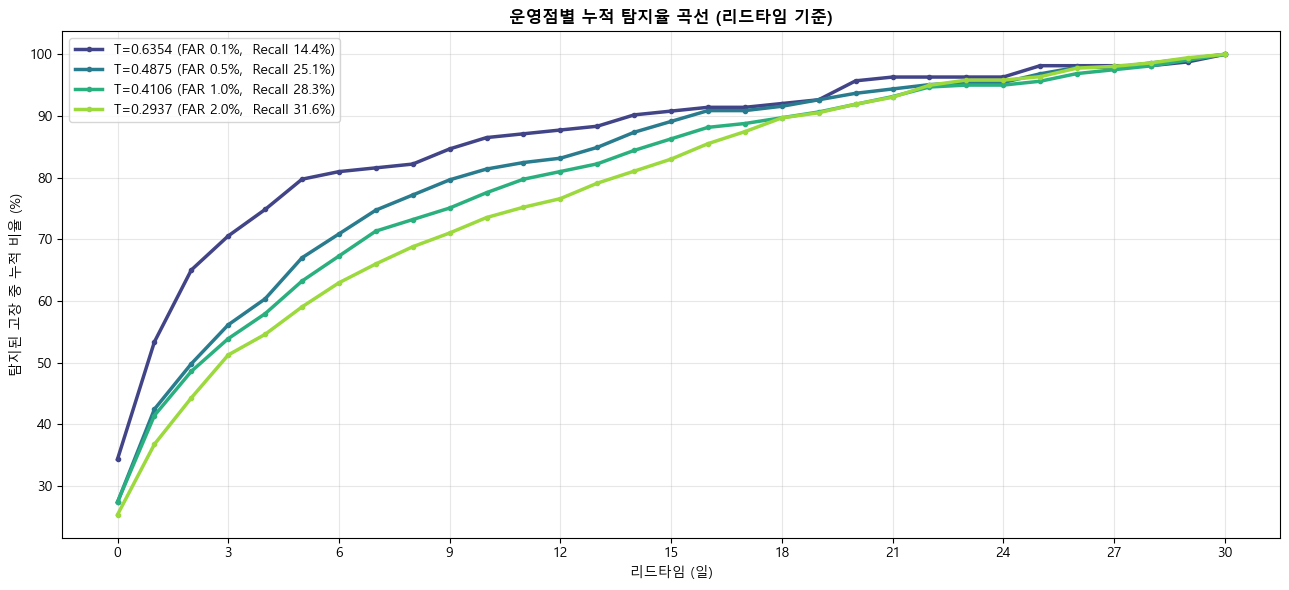

In [8]:
day_bins = list(range(0, 31))
fig, ax = plt.subplots(figsize=(13, 6))

palette = plt.cm.viridis(np.linspace(0.2, 0.85, len(op_points)))
for op, color in zip(op_points, palette):
    T = op["threshold"]
    tp_, *_ = classify_disks(T)
    if len(tp_) == 0: continue
    lts = tp_["lead_time"].values
    cum_pcts = [(lts <= d).mean()*100 for d in day_bins]
    ax.plot(day_bins, cum_pcts, lw=2.5, marker="o", markersize=3, color=color,
            label=f"T={T:.4f} (FAR {op['far_cap']*100:.1f}%,  Recall {len(tp_)/n_failed*100:.1f}%)")

ax.set_xlabel("리드타임 (일)"); ax.set_ylabel("탐지된 고장 중 누적 비율 (%)")
ax.set_title("운영점별 누적 탐지율 곡선 (리드타임 기준)", fontweight="bold")
ax.legend(fontsize=10); ax.grid(alpha=0.3)
ax.set_xticks(range(0,31,3))

plt.tight_layout()
plt.savefig("reports2/plots/08c_cumulative_detection.png", dpi=150)
plt.show()

## 6. 요약 저장

In [9]:
rows = []
for op in op_points:
    T = op["threshold"]
    tp_, fp_n_, fp_e_, fn_ = classify_disks(T)
    lts = tp_["lead_time"].values if len(tp_) > 0 else np.array([])
    rows.append({
        "far_cap_%":      op["far_cap"]*100,
        "threshold":      T,
        "test_far_%":     round(len(fp_n_)/n_normal*100,3),
        "test_recall_%":  round(len(tp_)/n_failed*100,3),
        "precision_%":    round(len(tp_)/(len(tp_)+len(fp_n_))*100,3) if (len(tp_)+len(fp_n_))>0 else 0,
        "TP":  len(tp_), "FP_normal": len(fp_n_),
        "FP_early": len(fp_e_), "FN": len(fn_),
        "lead_mean": round(lts.mean(),1) if len(lts)>0 else None,
        "lead_median": round(np.median(lts),1) if len(lts)>0 else None,
        "lead_7d_%":  round((lts<=7).mean()*100,1)  if len(lts)>0 else None,
        "lead_14d_%": round((lts<=14).mean()*100,1) if len(lts)>0 else None,
        "lead_30d_%": round((lts<=30).mean()*100,1) if len(lts)>0 else None,
    })

df_summary = pd.DataFrame(rows)
os.makedirs("reports2", exist_ok=True)
df_summary.to_csv("reports2/08c_leadtime_summary.csv", index=False, encoding="utf-8-sig")
print("저장: reports2/08c_leadtime_summary.csv")
display(HTML("<h4>최종 요약 테이블</h4>"))
display(df_summary)

저장: reports2/08c_leadtime_summary.csv


,far_cap_%,threshold,test_far_%,test_recall_%,precision_%,TP,FP_normal,FP_early,FN,lead_mean,lead_median,lead_7d_%,lead_14d_%,lead_30d_%
0,0.1,0.635364,0.128,14.361,95.322,163,8,32,972,4.2,1.0,81.6,90.2,100.0
1,0.5,0.487513,0.817,25.110,84.821,285,51,100,850,5.6,3.0,74.7,87.4,100.0
2,1.0,0.410590,1.169,28.282,81.472,321,73,126,814,6.1,3.0,71.3,84.4,100.0
3,2.0,0.293707,2.354,31.630,70.949,359,147,215,776,6.8,3.0,66.0,81.1,100.0
